In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score


In [7]:
df = pd.read_csv("D:\\Programing World\\Project Alfa\\Mall_Customers.csv")
df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,57,48,37
1,Male,35,45,74
2,Male,64,103,95
3,Male,18,86,30
4,Female,50,42,83


In [8]:
df.shape


(5000, 4)

In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Gender                  5000 non-null   object
 1   Age                     5000 non-null   int64 
 2   Annual Income (k$)      5000 non-null   int64 
 3   Spending Score (1-100)  5000 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 156.4+ KB


In [10]:
df.describe()


,Age,Annual Income (k$),Spending Score (1-100)
count,5000.000000,5000.000000,5000.000000
mean,38.833600,60.035800,49.666400
std,12.897798,25.533721,24.078868
min,18.000000,15.000000,1.000000
25%,29.000000,41.000000,32.000000
50%,39.000000,60.000000,49.000000
75%,48.000000,77.000000,67.000000
max,70.000000,143.000000,100.000000


In [11]:
df["Gender"] = df["Gender"].map({"Male": 0, "Female": 1})


In [12]:
df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,57,48,37
1,0,35,45,74
2,0,64,103,95
3,0,18,86,30
4,1,50,42,83


In [13]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)


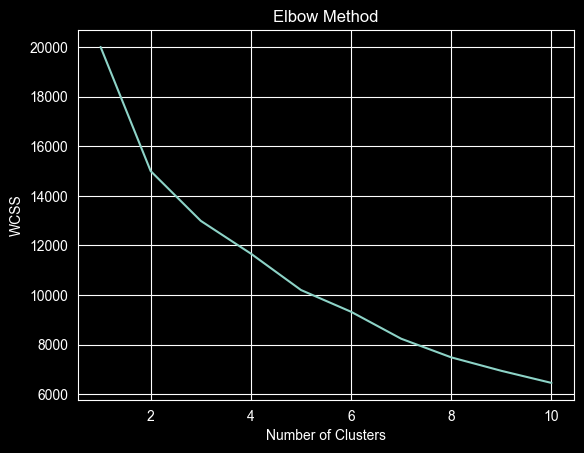

In [14]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()


In [15]:
kmeans = KMeans(n_clusters=5, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(scaled_data)


In [16]:
df.head()


,Gender,Age,Annual Income (k$),Spending Score (1-100),KMeans_Cluster
0,0,57,48,37,2
1,0,35,45,74,3
2,0,64,103,95,2
3,0,18,86,30,2
4,1,50,42,83,4


In [17]:
sil_kmeans = silhouette_score(scaled_data, df["KMeans_Cluster"])
print("Silhouette Score (K-Means):", sil_kmeans)


Silhouette Score (K-Means): 0.21768381217489


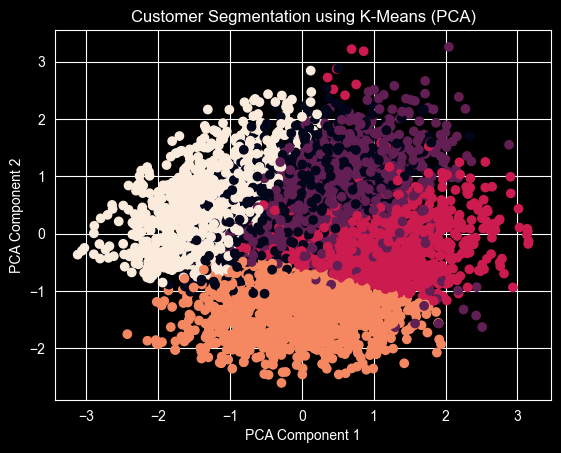

In [18]:
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df["KMeans_Cluster"])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using K-Means (PCA)")
plt.show()


In [19]:
dbscan = DBSCAN(eps=1.2, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(scaled_data)


In [20]:
df["DBSCAN_Cluster"].value_counts()


DBSCAN_Cluster
1    2867
0    2133
Name: count, dtype: int64

In [21]:
labels = df["DBSCAN_Cluster"]
mask = labels != -1

sil_dbscan = silhouette_score(scaled_data[mask], labels[mask])
print("Silhouette Score (DBSCAN):", sil_dbscan)


Silhouette Score (DBSCAN): 0.27321870057230796


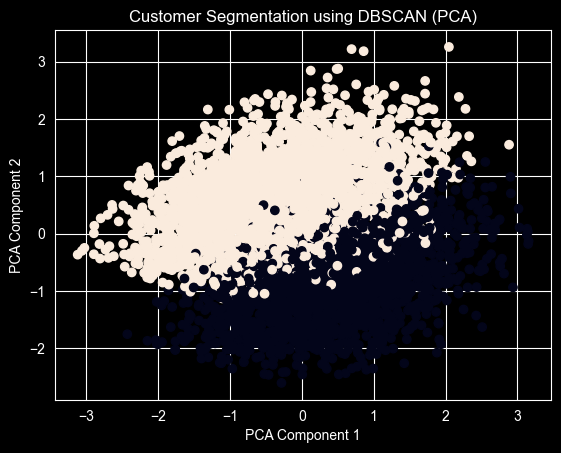

In [22]:
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=df["DBSCAN_Cluster"])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Customer Segmentation using DBSCAN (PCA)")
plt.show()


In [23]:
cluster_summary = df.groupby("KMeans_Cluster").mean()
cluster_summary


,Gender,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster
KMeans_Cluster,,,,,
0,0.994726,30.760549,69.088608,30.754219,0.994726
1,0.985386,52.866388,56.846555,45.181628,0.985386
2,0.007071,43.185859,81.340404,49.775758,0.007071
3,0.000000,35.293700,41.715173,49.197870,0.000000
4,0.995906,32.580348,53.924258,72.844422,0.995906


In [24]:
cluster_size = df["KMeans_Cluster"].value_counts().sort_index()

cluster_summary["Customer_Count"] = cluster_size
cluster_summary


,Gender,Age,Annual Income (k$),Spending Score (1-100),DBSCAN_Cluster,Customer_Count
KMeans_Cluster,,,,,,
0,0.994726,30.760549,69.088608,30.754219,0.994726,948
1,0.985386,52.866388,56.846555,45.181628,0.985386,958
2,0.007071,43.185859,81.340404,49.775758,0.007071,990
3,0.000000,35.293700,41.715173,49.197870,0.000000,1127
4,0.995906,32.580348,53.924258,72.844422,0.995906,977
